## In this notebook we will
1. See the circularity of FFTs in action
2. Examine the source of spectral leakage
3. Reduce leakage by using a window function

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    # Figure & Resolution
    'figure.figsize': (3, 1.5),      # Standard rectangular size
    'figure.dpi': 100,             # High resolution for saving
    'savefig.dpi': 300,            # High resolution for exported images
    'savefig.bbox': 'tight',       # Removes unnecessary white space around the plot
    
    # Fonts & Text
    'font.family': 'sans-serif',   # Use serif for traditional journals, sans-serif for modern
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,               # Base font size
    'axes.titlesize': 10,          # Title size
    'axes.labelsize': 10,          # X and Y label size
    'xtick.labelsize': 10,         # Tick label size
    'ytick.labelsize': 10,         # Tick label size
    'legend.fontsize': 10,         # Legend text size
    
    # Axes & Spines (The "Clean" Look)
    'axes.spines.top': False,      # Remove top bounding box line
    'axes.spines.right': False,    # Remove right bounding box line
    'axes.linewidth': 1.1,         # Slightly thicker axes lines
    'axes.grid': False,            # Default to no grid (turn on manually if needed)
    
    # Ticks
    'xtick.direction': 'in',       # Ticks point inward
    'ytick.direction': 'in',       # Ticks point inward
    'xtick.major.size': 6,         # Major tick length
    'xtick.major.width': 1.2,      # Major tick thickness
    'ytick.major.size': 6,         # Major tick length
    'ytick.major.width': 1.2,      # Major tick thickness
    
    # Lines & Markers
    'lines.linewidth': 1.5,        # Thicker lines for visibility
    'lines.markersize': 4,         # Standard marker size
    
    # Legend
    'legend.frameon': False,       # Remove the box around the legend
    'legend.loc': 'best'           # Automatically place legend out of the way
})

One of the most fundamental ideas in signal processing is that regular sampling in one domain introduces periodicity in the corresponding Fourier domain.

For example, sampling in time domain causes the fourier transform of the sampled timestream to be periodic.

Say we have a sine wave $e^{j2 \pi f t}$, and I sample it at a rate $f_s$.  What will I see? We have $e^{j2 \pi f \frac{n}{f_s}}$. 

If $f > f_s$, what will I see then? Let $f = f_s + \Delta f$. 

We will observe $e^{j2 \pi (f_s + \Delta f) \frac{n}{f_s}} = \underbrace{e^{j2 \pi n}}_{1} e^{j2 \pi \Delta f \frac{n}{f_s}}$. 

A sine wave of frequency higher than sampling rate is indistinguisable from $f\pmod{f_s}$. This means that the spectrum is periodic with a period of $f_s$.

Frequency was a continuous variable but the exact logic can also be used when we sample in frequency space. What if I only store a discrete number of frequencies? Say, only integer multiples of $f_s/N$?

A sine wave of frequency that is an integer multiple of $f_s/N$ can be written as $e^{j2 \pi k \Delta f \frac{n}{f_s}} = e^{j2 \pi k \frac{f_s}{N} \frac{n}{f_s}} = e^{j2 \pi k n/N}$. But now the signal has become periodic in time. I cannot differentiate between samples $n$ and $n\pmod{N}$. This means that if I sample both time and frequency on a regular grid, I've just made my signal circular. This is the domain of Discrete Fourier Transform.

### Circularity in action
Delaying a signal

Delay in time domain is a phase ramp in frequency domain. Change delay amount and see it shift.

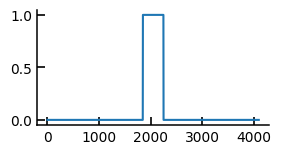

In [4]:
N = 4096
x = np.zeros(N)
x[N//2-200:N//2+200] = 1
plt.plot(x)

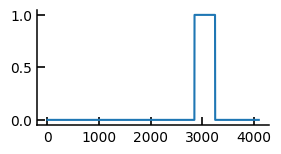

In [7]:
#delay it
delay = 1000
chans = np.arange(len(x))
x_delayed = np.fft.ifft(np.fft.fft(x) * np.exp(-2j*np.pi*chans*delay/N)).real
plt.plot(x_delayed)

What does a delay of more than 4000 do?

#### We must be very careful with causality when using FFTs. 

FFT doesn't care about whether your data is actually circulant or not. Since we cannot distinguish between sample N-1 and -1 in a circular buffer, it is up to you, the analyst, to decide if N-1 is the actual future or not.

In [ ]:
gaussian1 = np.exp(-np.linspace(-N//2

### Spectral Leakage

We will compare a sine wave at an integer frequency vs a fractional frequency

In [31]:
k1=10                    # UNITLESS FREQUENCY 10 cycles in N samples
N=4096
n = np.arange(N)
x1 = np.cos(2*np.pi*k1*n/N) # THIS IS OUR BASELINE SIGNAL
fx1 = np.fft.rfft(x1)

#### We'll sweep through a channel width to see what happens when it's NOT an integer

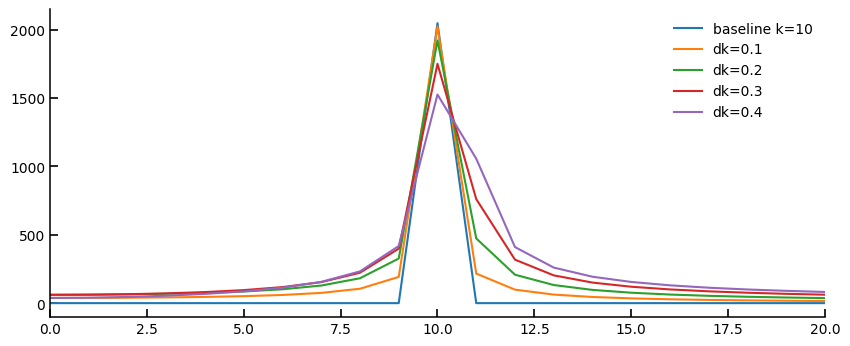

In [40]:
fig=plt.figure(figsize=(10,4))

dks = [0.1, 0.2, 0.3, 0.4]

plt.plot(np.abs(fx1), label=f'baseline k={k1}')

for dk in dks:
    x2 = np.cos(2*np.pi*(k1+dk)*n/N)
    fx2 = np.fft.rfft(x2)
    _=plt.plot(np.abs(fx2), label=f'dk={dk}')
_=plt.legend()
_=plt.xlim(k1-10,k1+10)

We notice that as we move **farther** from channel center, we leak more and more into neighboring channels. The leakage is not insiginicant either. At $dk=0.4$, we're leaking 10% of the peak amplitude 10 channels away!

#### There are several ways to understand this phenomenon. 

The simplest is to look at the circular version of a off-channel-center sine wave that a DFT "sees".

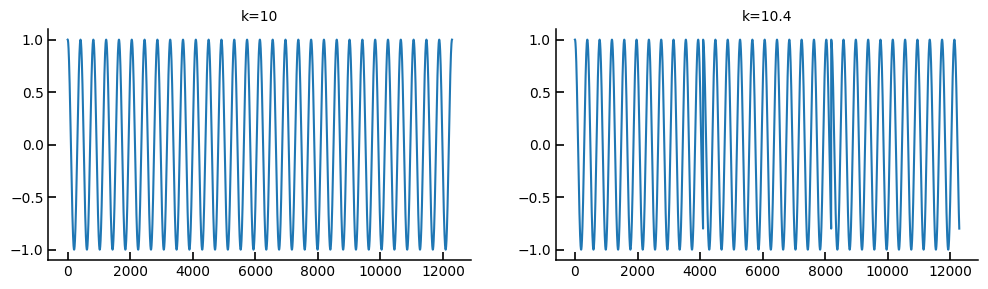

In [46]:
#Repeat the signal a few times and zoom in on k=10 vs k=10.4

fig=plt.figure(figsize=(12,3))
plt.subplot(121)
plt.title('k=10')
plt.plot(np.tile(x1,3))

plt.subplot(122)
plt.title('k=10.4')
plt.plot(np.tile(x2,3))

Do you notice a change?

Because the off-channel-center sine wave is not periodic across two consecutive blocks, there's a sharp edge. The only way to represent a sharp edge with sine waves is to use all of them.

One way to reduce the leakage artefact is to make a block of data that is not circulant slowly approach zero towards the edges, so that it gets closer to being circulant. This is called windowing.

#### Repeat the exercise with a window function multiplying the signal

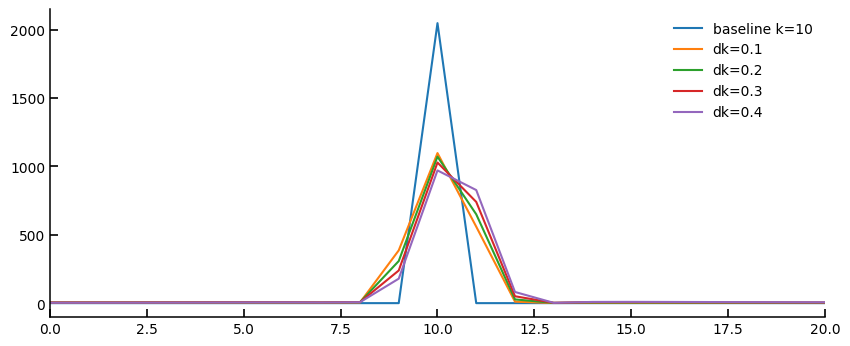

In [51]:
fig=plt.figure(figsize=(10,4))

dks = [0.1, 0.2, 0.3, 0.4]

x1 = np.cos(2*np.pi*k1*n/N)
fx1 = np.fft.rfft(x1)
plt.plot(np.abs(fx1), label=f'baseline k={k1}')

for dk in dks:
    x2 = np.cos(2*np.pi*(k1+dk)*n/N) * np.hamming(N)
    fx2 = np.fft.rfft(x2)
    _=plt.plot(np.abs(fx2), label=f'dk={dk}')
_=plt.legend()
_=plt.xlim(k1-10,k1+10)

Ignoring the scaling factor, we can see that all spectra cluster closer and have decayed much faster.